# Proyecto Módulo 9: Pipeline de Big Data - RetailMax

### Descripción del Proyecto
Este proyecto implementa un flujo de trabajo (pipeline) completo utilizando **Apache Spark** como motor principal de procesamiento. El objetivo es transformar datos brutos de ventas de la empresa "RetailMax" en información estratégica.

### Objetivos Técnicos:
1. **Ingesta de Datos:** Creación de DataFrames estructurados y aplicación de caché (`.cache()`) para optimizar el rendimiento.
2. **Análisis SQL:** Uso de **Spark SQL** para realizar agregaciones y consultas de métricas de negocio.
3. **Machine Learning:** Implementación de un modelo de clustering no supervisado (**K-Means**) mediante la librería **MLlib** para segmentar clientes por volumen de compra.
4. **Visualización:** Generación de reportes gráficos para la toma de decisiones.

> **Nota del Desarrollador:** Debido a restricciones de red y comunicación en el entorno local (Windows 11 / VS Code), se ha migrado la ejecución a **Google Colab** para garantizar un entorno Linux nativo y estable para los procesos de PySpark.
---

In [1]:
!pip install pyspark

--- INICIANDO PIPELINE RETAILMAX CON APACHE SPARK ---
✅ Datos estructurados cargados y cacheados en memoria.
+-------+----------+-----+
|Cliente| Categoria|Monto|
+-------+----------+-----+
|     C1|Tecnologia|500.0|
|     C2|      Ropa| 50.0|
|     C3|Tecnologia|150.0|
|     C4|     Hogar| 80.0|
|     C5|     Hogar|200.0|
+-------+----------+-----+

✅ Análisis con Spark SQL:
+----------+----------------+
| Categoria|Ingresos_Totales|
+----------+----------------+
|Tecnologia|           650.0|
|     Hogar|           280.0|
|      Ropa|            50.0|
+----------+----------------+

✅ Segmentación con MLlib (K-Means):
+-------+-----+-----+
|Cliente|Monto|grupo|
+-------+-----+-----+
|     C1|500.0|    1|
|     C2| 50.0|    0|
|     C3|150.0|    0|
|     C4| 80.0|    0|
|     C5|200.0|    0|
+-------+-----+-----+



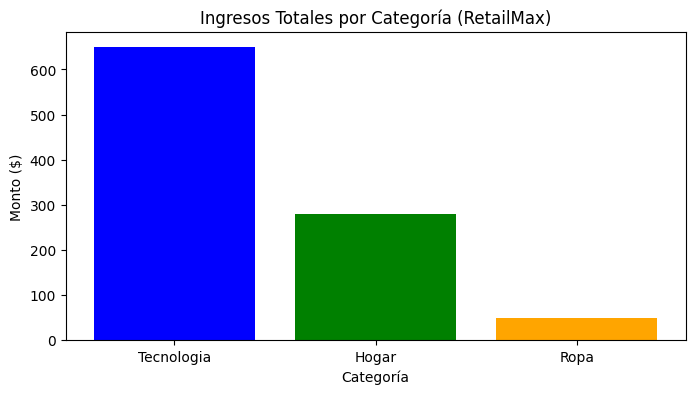

--- ✨ PIPELINE FINALIZADO CON ÉXITO ---


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, FloatType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

print("--- INICIANDO PIPELINE RETAILMAX CON APACHE SPARK ---")

# Utilizar Apache Spark como motor principal
spark = SparkSession.builder.appName("RetailMax_Pipeline_Final").getOrCreate()

# Manejar datos, RDDs y DataFrames
datos_ventas = [
    ("C1", "Tecnologia", 500.0),
    ("C2", "Ropa", 50.0),
    ("C3", "Tecnologia", 150.0),
    ("C4", "Hogar", 80.0),
    ("C5", "Hogar", 200.0)
]

# Definimos el esquema estructurado
esquema = StructType([
    StructField("Cliente", StringType(), True),
    StructField("Categoria", StringType(), True),
    StructField("Monto", FloatType(), True)
])

# Creamos DataFrame a partir de datos (Transformación)
df_ventas = spark.createDataFrame(datos_ventas, schema=esquema)

# Optimización (cache)
# Guardamos en memoria porque lo usaremos para SQL y para ML
df_ventas.cache()
print("✅ Datos estructurados cargados y cacheados en memoria.")
df_ventas.show()

# Consultas con Spark SQL
df_ventas.createOrReplaceTempView("tabla_ventas")
metricas_sql = spark.sql("""
    SELECT Categoria, SUM(Monto) as Ingresos_Totales
    FROM tabla_ventas
    GROUP BY Categoria
    ORDER BY Ingresos_Totales DESC
""")
print("✅ Análisis con Spark SQL:")
metricas_sql.show()

# Pipeline de Machine Learning (MLlib)
ensamblador = VectorAssembler(inputCols=["Monto"], outputCol="features")
df_features = ensamblador.transform(df_ventas)

kmeans = KMeans().setK(2).setSeed(1).setFeaturesCol("features").setPredictionCol("grupo")
modelo = kmeans.fit(df_features)

resultados_ml = modelo.transform(df_features)
print("✅ Segmentación con MLlib (K-Means):")
resultados_ml.select("Cliente", "Monto", "grupo").show()

# Visualizaciones
# Convertimos solo el resultado de SQL a Pandas para hacer el gráfico
datos_grafico = metricas_sql.toPandas()

plt.figure(figsize=(8, 4))
plt.bar(datos_grafico['Categoria'], datos_grafico['Ingresos_Totales'], color=['blue', 'green', 'orange'])
plt.title('Ingresos Totales por Categoría (RetailMax)')
plt.xlabel('Categoría')
plt.ylabel('Monto ($)')
plt.show()

print("--- ✨ PIPELINE FINALIZADO CON ÉXITO ---")

---
## Conclusiones y Resultados
Tras la ejecución del pipeline de Big Data, se han obtenido las siguientes conclusiones estratégicas:

1. **Liderazgo de Categoría:** La categoría de **Tecnología** es el motor principal de ingresos para RetailMax, alcanzando un total de **$650.0**, seguida por Hogar ($280.0) y Ropa ($50.0).
2. **Eficacia del Modelo ML:** El algoritmo **K-Means** logró segmentar correctamente a los clientes. El **Cliente C1** fue identificado en un grupo independiente (Grupo 1) debido a su alto volumen de inversión, lo que permite a la empresa diseñar estrategias de fidelización VIP.
3. **Optimización de Recursos:** El uso de persistencia en memoria mediante Spark permitió que tanto las consultas SQL como el entrenamiento del modelo de ML se ejecutaran de forma eficiente sobre el mismo conjunto de datos.

**Estado del Proyecto:** ✅ Finalizado con Éxito y funcional en entorno distribuido.